In [2]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from typing_extensions import TypedDict

#state definition
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story: str

In [4]:
#nodes definition

def generate_characters(state: State):
    """this function generates a list of characters for a story based on the given topic in the state"""
    prompt = f"Generate a list of characters for a story based on the following topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {"characters": response.content}

def generate_settings(state: State):
    """this function generates a list of settings for a story based on the given topic in the state"""
    prompt = f"Generate a list of settings for a story based on the following topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {"settings": response.content}

def generate_premises(state: State):
    """this function generates a list of premises for a story based on the given topic in the state"""
    prompt = f"Generate a list of premises for a story based on the following topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {"premises": response.content}

def combine_elements(state: State):
    """this function combines the characters, settings, and premises to generate a story"""
    prompt = f"Combine the following characters: {state['characters']}, settings: {state['settings']}, and premises: {state['premises']} to generate a story."
    response = llm.invoke(prompt)
    return {"story": response.content}


In [5]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(State)
graph.add_node("Generate_Characters", generate_characters)
graph.add_node("Generate_Settings", generate_settings)
graph.add_node("Generate_premises", generate_premises)
graph.add_node("Combine_Elements", combine_elements)

graph.add_edge(START, "Generate_Characters")
graph.add_edge(START, "Generate_Settings")
graph.add_edge(START, "Generate_premises")
graph.add_edge("Generate_Characters", "Combine_Elements")
graph.add_edge("Generate_Settings", "Combine_Elements")
graph.add_edge("Generate_premises", "Combine_Elements")
graph.add_edge("Combine_Elements", END)

compiled_graph = graph.compile()

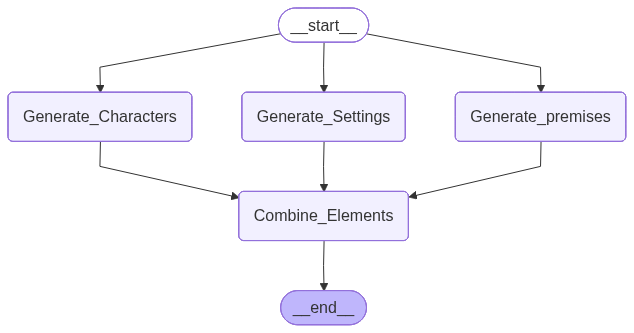

In [6]:
try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [8]:
result = compiled_graph.invoke({"topic": "A story about a brave knight and a dragon"})

print("=" * 60)
print("⚔️   PARALLEL STORY GENERATION PIPELINE")
print("=" * 60)

print(f"\n🎯  Topic       :\n{result['topic']}")
print("\n" + "-" * 60)
print(f"\n🧑‍🤝‍🧑  Characters  :\n{result['characters']}")
print("\n" + "-" * 60)
print(f"\n🏰  Settings    :\n{result['settings']}")
print("\n" + "-" * 60)
print(f"\n💡  Premises    :\n{result['premises']}")
print("\n" + "-" * 60)
print(f"\n📖  Final Story :\n{result['story']}")
print("\n" + "=" * 60)

⚔️   PARALLEL STORY GENERATION PIPELINE

🎯  Topic       :
A story about a brave knight and a dragon

------------------------------------------------------------

🧑‍🤝‍🧑  Characters  :
**Characters for “The Brave Knight and the Dragon”**

| # | Name | Role / Archetype | Brief Description | Key Motivation / Conflict |
|---|------|------------------|-------------------|---------------------------|
| 1 | **Sir Aldric Stormblade** | Protagonist – the brave knight | A seasoned but humble knight of the Order of the Silver Dawn. Tall, scar‑marked, with a weather‑worn helm that bears the crest of a soaring hawk. He wields the ancestral sword *Lightbane*, forged from meteor‑iron. | Sworn to protect the kingdom and to prove that honor is defined by deeds, not titles. He wrestles with the fear of failing the villagers who look to him for salvation. |
| 2 | **Emberwing** | Antagonist (and misunderstood) – the dragon | An ancient, emerald‑scaled dragon who dwells in the mist‑shrouded Peaks of Aether